In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [2]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

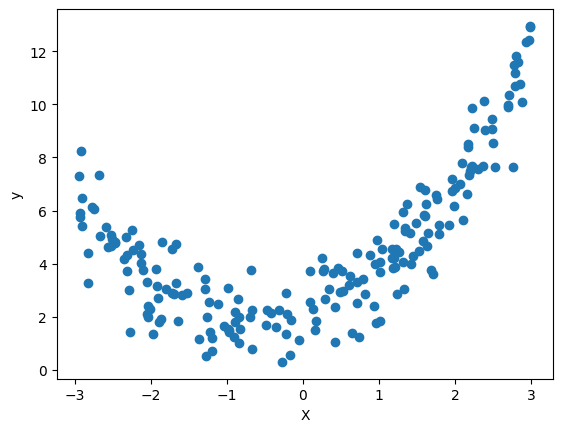

In [6]:
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [13]:
lr = LinearRegression()

In [14]:
lr.fit(X_train,y_train)

LinearRegression()

In [15]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.3153334687755479

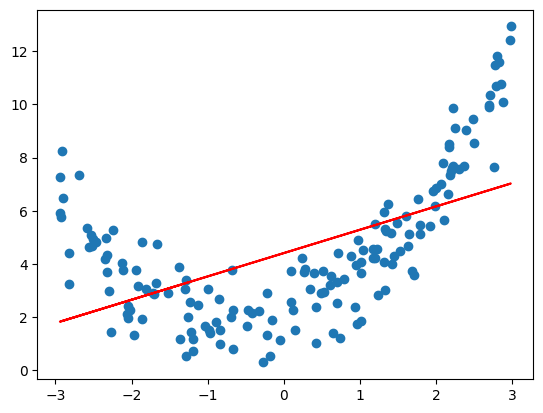

In [18]:
plt.plot(X_train,lr.predict(X_train),color='red')
plt.scatter(X_train,y_train)

In [76]:
poly = PolynomialFeatures(degree=2,include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [77]:
X_train_trans

array([[ 1.00000000e+00, -2.90407708e+00,  8.43366371e+00],
       [ 1.00000000e+00,  2.84980984e+00,  8.12141611e+00],
       [ 1.00000000e+00,  9.64858073e-01,  9.30951100e-01],
       [ 1.00000000e+00,  6.47878717e-01,  4.19746832e-01],
       [ 1.00000000e+00, -2.91637322e+00,  8.50523275e+00],
       [ 1.00000000e+00,  1.19472564e+00,  1.42736936e+00],
       [ 1.00000000e+00, -2.52216653e+00,  6.36132400e+00],
       [ 1.00000000e+00, -1.86754160e+00,  3.48771162e+00],
       [ 1.00000000e+00,  2.16739843e+00,  4.69761595e+00],
       [ 1.00000000e+00,  1.32836677e+00,  1.76455827e+00],
       [ 1.00000000e+00,  4.25567968e-01,  1.81108096e-01],
       [ 1.00000000e+00,  5.31064491e-01,  2.82029494e-01],
       [ 1.00000000e+00, -1.75318971e-01,  3.07367415e-02],
       [ 1.00000000e+00,  2.71326952e+00,  7.36183148e+00],
       [ 1.00000000e+00,  1.70611642e+00,  2.91083325e+00],
       [ 1.00000000e+00,  1.31073683e+00,  1.71803103e+00],
       [ 1.00000000e+00,  1.63352137e+00

In [78]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [79]:
y_pred = lr.predict(X_test_trans)

In [80]:
r2_score(y_test,y_pred)

0.9238463103279257

In [81]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.88150609 0.77364954]]
[2.02228953]


In [82]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

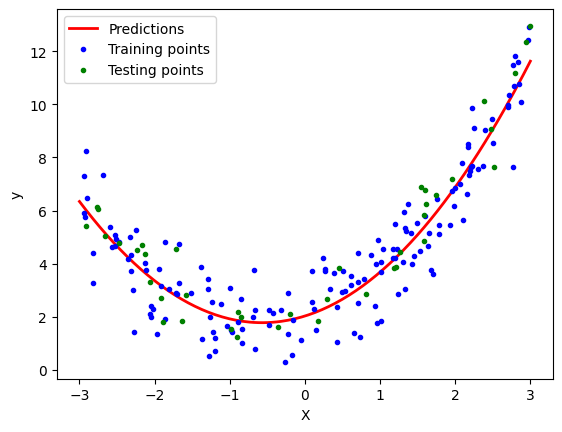

In [83]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()